In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [15]:
df = pd.read_csv("sales_data.csv")

In [17]:
X = df[['Sales_Amount', 'Quantity_Sold', 'Discount']]

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [20]:
print(df.head())

   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  Cluster  
0           Cash        Online            North-Bob        1  
1       

In [21]:
print(df.columns)

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep', 'Cluster'],
      dtype='object')


In [22]:
print(df[['Sales_Amount', 'Quantity_Sold', 'Discount', 'Cluster']].head())

   Sales_Amount  Quantity_Sold  Discount  Cluster
0       5053.97             18      0.09        1
1       4384.02             17      0.11        2
2       4631.23             30      0.20        0
3       2167.94             39      0.02        2
4       3750.20             13      0.08        2


In [23]:
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())


Cluster Distribution:
Cluster
2    389
0    326
1    285
Name: count, dtype: int64


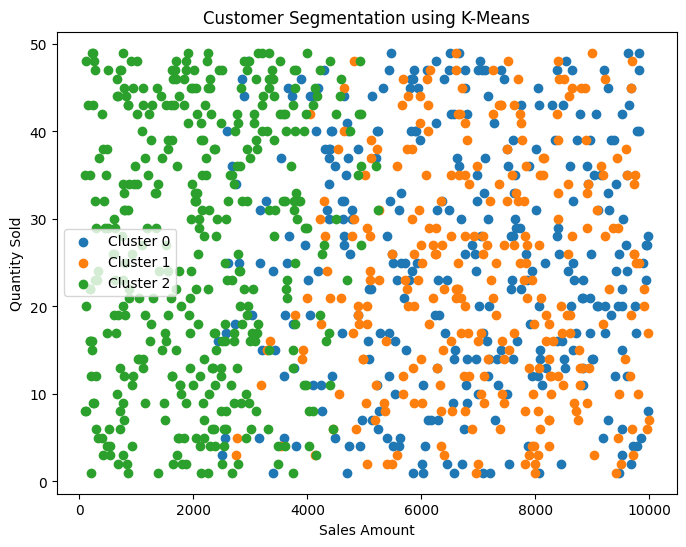

In [24]:
plt.figure(figsize=(8,6))

for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Sales_Amount'],
                cluster_data['Quantity_Sold'],
                label=f'Cluster {i}')

plt.xlabel("Sales Amount")
plt.ylabel("Quantity Sold")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()